<h1><center>Workshop on Computer Vision for Image Segmentation</center></h1>

Prepared by **Vladimir PIMONOV**  
Affiliation: [ILM / Team PNEC]  
Contact: [foxlightmanstudes@gmail.com]

These notebooks were prepared for the workshop and are intended as guided practical material.  
They can also be used independently outside the workshop.  
For questions, feedback, or bug reports, please contact the author.

<h2><center>PW 03. Selecting and training the models</center></h2>

In this notebook, we move from data preparation to **actual model training**.

The goal is to build a complete segmentation workflow:

1. import the utility functions prepared in the previous practical works,
2. choose a model architecture,
3. load the training, validation, and test datasets,
4. define the optimization strategy,
5. train the model,
6. evaluate it on validation data,
7. save the trained weights,
8. use the model for prediction on patches and on larger images.

This is the most important practical work of the course, because it brings together all the previous steps into one usable pipeline.

Even for users who do not attend the workshop, this notebook is meant to remain understandable as a standalone training example.

## 1. Import the required libraries

We begin by importing the packages used throughout the training workflow.

These libraries cover several different roles:

- **general Python utilities** for file handling, randomness, and saving results,
- **scientific Python tools** such as NumPy and pandas,
- **image-reading tools** for TIFF microscopy data,
- **PyTorch modules** for neural networks, tensors, losses, and optimization,
- **visualization tools** for inspecting images and predictions.

At this stage, this is simply the technical environment needed to run the notebook.  
The training logic itself will come from the custom functions and model classes imported in the next step.

In [1]:
import os
from os.path import join as pjoin
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import matplotlib.pyplot as plt

import pandas as pd

import tifffile
from tifffile import TiffFile

from PIL import Image, ImageOps

import numpy as np
import torch
import torch.utils.data

from itertools import product

import random

from torchvision.transforms import functional as TF

from tqdm.notebook import tqdm # use this tqdm for Jupyter
# from tqdm import tqdm # use this tqdm for VSCode

import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

from sys import platform
if platform == "win32":
    import winsound

## 2. Load the models and helper functions from the workshop library

In the previous practical works, we defined transformations utility functions directly inside the notebooks.

Now that these functions have become stable and reusable, they are moved into separate `.py` files and imported as a small library.

In addition there are more other utility functions that will be used for other taskts described below.

This has several advantages:

- the notebook becomes cleaner and easier to read,
- the same code can be reused in multiple notebooks,
- bug fixes only need to be made in one place,
- training scripts become more reproducible.

The imported modules play different roles:

- **`engine`** contains the training and evaluation loops,
- **`loss_functions`** contains several segmentation losses,
- **`transforms`** contains the data augmentation and collation tools,
- **`models`** contains the segmentation architectures,
- **`inference`** contains helper functions for prediction on patches or larger tiled images.

In [2]:
from scripts.engine import *
from scripts.engine import _batch_to_tensor, _batch_to_tensor_mc
from scripts.loss_functions import *
from scripts.transforms import *

# Library of models and inferences (Deep versions of UNet and UNet++ are legacy versions that have been used for training)
from scripts.models.UNetPPResNetDeep_lagacy import UNetPPResNetDeep as UNetPPResNetDeep_l
from scripts.models.UNetResNetDeep_legacy import UNetResNetDeep as UNetResNetDeep_l
from scripts.models.UNet3PlusResNet34 import UNet3PlusResNet34
from scripts.models.UNet3PlusResNet50Deep import UNet3PlusResNet50Deep
from scripts.models.UNetPPResNet34 import UNetPPResNet34
from scripts.models.UNetResNet34 import UNetResNet34
from scripts.inference import infer_full_image_tiled, infer_patch, filter_mask_by_confident_overlap

## 3. Check whether GPU acceleration is available

Inference can be performed on either a GPU or a CPU.

A GPU is usually much faster, especially for large images or tiled inference over many patches.  
This quick check tells us whether CUDA is available on the current machine.

If no GPU is available, the notebook can still run on CPU, but prediction will usually take more time.

In [2]:
### Check if cuda (gpu acceleration is avaliable)
torch.cuda.is_available()

True

## 4. Select the computation device

Here we define the device on which the model will run.

This device setting will later be used both for:

- the neural network itself,
- and the tensors created from the input images.

Keeping the model and the input on the same device is essential.  
Otherwise, PyTorch cannot execute the forward pass correctly.

In [3]:
### Use gpu acceleration if possible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 5. Select the model architecture

Here we choose which neural network architecture will be trained.

All proposed models belong to the same broad family: **encoder-decoder segmentation networks**.  
They all take an image as input and return a pixelwise prediction map of the same size.

### The common idea behind these models

In this family of models, the network usually has two main parts:

- an **encoder**, which progressively reduces spatial resolution while extracting more abstract features,
- a **decoder**, which progressively reconstructs a detailed segmentation map.

The encoder answers the question: *what is present in the image?*  
The decoder answers the question: *where exactly is it?*

### Models available in this notebook

Two implementation families are available in this notebook: **Classic** and **Deep**.

#### Classic models
The **Classic** versions correspond to architectures described in the original literature, with the references given below.  
They follow the standard depth of the published models and are usually the safest starting point for training and comparison.

#### Deep models
The **Deep** versions are extended implementations created for this workshop.  
Their encoder-decoder structure includes additional downsampling and upsampling levels compared with the classic variants.

The main consequence is a **larger receptive field**: each output pixel can depend on information coming from a wider region of the input image. This can be useful when the segmentation decision depends not only on local boundaries, but also on broader spatial context.

This increased depth comes with an important practical constraint: the input patches must be large enough.  
Each downsampling stage reduces the spatial size of the feature maps. If the input patch is too small, repeated reductions can make the feature map collapse to an invalid or nearly empty spatial size. In practice, this means that the network reaches a limit where the deepest feature maps become too small to carry useful spatial information.

This issue is commonly described as a **spatial collapse** of the feature maps.  
For that reason, deeper models usually require **larger input patches** than their classic counterparts.

#### 1. U-Net classic
This is the reference encoder-decoder architecture introduced for biomedical image segmentation.  
Its key idea is the use of **skip connections** between encoder and decoder levels, which helps preserve fine spatial details.

Seminal paper:  
[U-Net: Convolutional Networks for Biomedical Image Segmentation](https://arxiv.org/abs/1505.04597)

#### 2. U-Net Deep
This version extends the network with additional encoder and decoder levels.  
The goal is to increase the **receptive field**, meaning that each output pixel can depend on a larger image context.

This can be useful when segmentation depends not only on local boundaries but also on broader structural context.

#### 3. U-Net++ classic
U-Net++ modifies the skip connections.  
Instead of linking encoder and decoder levels directly only once, it introduces **nested skip pathways** that progressively reduce the semantic gap between low-level and high-level features.

This often improves boundary refinement, at the cost of greater complexity.

Seminal paper:  
[UNet++: A Nested U-Net Architecture for Medical Image Segmentation](https://arxiv.org/abs/1807.10165)

#### 4. U-Net++ Deep
This is a deeper version of U-Net++, combining nested skip connections with a larger receptive field.

It is usually heavier in memory and computation, but may be useful when the structures of interest vary strongly in size or when broader context is needed.

#### 5. U-Net 3+ classic
U-Net 3+ extends the skip-connection idea further by using **full-scale feature fusion**.  
At a given decoding level, it aggregates information coming from multiple encoder scales, not just from one corresponding skip level.

This can help the model combine fine local details and coarse global context more explicitly.

Seminal paper:  
[UNet 3+: A Full-Scale Connected UNet for Medical Image Segmentation](https://arxiv.org/abs/2004.08790)

#### 6. U-Net 3+ Deep
This is the deeper version of U-Net 3+, with an even larger context window.

It is the most computationally demanding architecture among the options shown here.

### Why all these models use ResNet backbones

The encoder part of these models is based on **ResNet**.  
A ResNet backbone is a feature extractor originally designed for image classification, built from **residual blocks** that make deeper networks easier to optimize.

Using a pretrained ResNet encoder often gives better feature extraction at the beginning of training.

Seminal paper:  
[Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385)

### Practical note

There is no universally best architecture.  
The choice depends on the task, the available GPU memory, the amount of data, and the type of structures to segment.

A good practical strategy is often:

- start with the simpler **U-Net** baseline,
- then compare it with **U-Net++** or **U-Net 3+** if better boundary quality or multi-scale fusion is needed.

In [5]:
### 1. U-Net classic
model = UNetResNet34(num_classes=1, pretrained_backbone=True, in_channels=1).to(device)

### 2. U-Net Deep
### (available with resnet 50 and resnet34, on inference available the resnet50 version)

# model = UNetResNetDeep_l(backbone="resnet34", in_channels=1, num_classes=1, pretrained=True).to(device)
# model = UNetResNetDeep_l(backbone="resnet50", in_channels=1, num_classes=1, pretrained=True).to(device)

### 3. U-Net++ classic
# model = UNetPPResNet34(num_classes=1, pretrained_backbone=True, in_channels=1).to(device)

### 4. U-Net++ Deep
# model = UNetPPResNetDeep_l(backbone="resnet50", in_channels=1, num_classes=1, pretrained=True,
#                         extra_down_channels=(1024, 1024),
#                         dec_channels=(64, 128, 256, 512, 512, 512, 512)).to(device)

### 5. U-Net3+ classic
# model = UNet3PlusResNet34(in_channels=1, num_classes=1, pretrained=True, fuse_ch=64).to(device)

### 6. U-Net3+ Deep
# model = UNet3PlusResNet50Deep(in_channels=1, num_classes=1, pretrained=True, fuse_ch=64).to(device)

## 6. Define the dataset class used for training

This is the same type of custom PyTorch dataset that we introduced in the previous practical work.

Its role is to connect the saved dataframe to the actual files on disk.  
For each sample, it:

1. reads the patch name from the dataframe,
2. loads the corresponding image and mask,
3. converts the mask into a binary target,
4. applies the chosen transformations,
5. returns the `(image, target)` pair.

At this stage, the dataset is no longer a new concept.  
It is the practical link between the dataframe prepared earlier and the training pipeline used in this notebook.

In [6]:
class DS_NPs(torch.utils.data.Dataset):
    
    def __init__(self, root, img_arr, transforms=None):
        ### initiate transforms
        self.root = root
        self.transforms = transforms
        self.img_list = img_arr.values
        
    def __getitem__(self, idx):
        # load images ad masks
        # load images ad masks
        img_path = os.path.join(self.root, "Images", self.img_list[idx]+'.tiff')
        mask_path = os.path.join(self.root, "Masks", self.img_list[idx]+'.tiff')
        
        with TiffFile(mask_path) as tif:
            mask = tif.asarray()
            
        target = (mask!=0).astype(int) ### binarize the mask
            
        with TiffFile(img_path) as tif:
            img = tif.asarray()
        
        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.img_list)

## 7. Define the augmentation pipeline used during training

This transformation pipeline follows the same logic as the one introduced in the previous practical work.

It combines:

- **format conversion** to tensors,
- **geometric augmentations** applied jointly to image and mask,
- **photometric augmentations** applied only to the image.

In this notebook, we simply reuse that logic as part of the training workflow.  
The objective here is no longer to study the transformations themselves in detail, but to use them correctly during model optimization.

As before:

- training data is augmented to improve robustness and reduce overfitting,
- validation and test data are kept unchanged apart from the necessary tensor conversion, so that evaluation remains stable and reproducible.

In [7]:
def get_transform(train):
    transforms = []
    # converts the image, a PIL image, into a PyTorch Tensor
    transforms.append(ToTensor())
    if train:
        # during training, randomly flip the training images
        # and ground-truth for data augmentation
        transforms.append(RandomOneOfFlip(0.5, 0.5))
        transforms.append(RandomRightAngleRotate())
        transforms.append(Adj_Brightness((0.5,1.5), 0.5))
        transforms.append(Adj_Contrast((0.5,4), 0.5))

        # cluster of transformations applicable only to PIL images
        # so first and last transformations are indispensable
        # however we won't use any of these transformations because our images are grayscale
        # transforms.append(T.ToPil()) # Not needed
        # transforms.append(T.Adj_Gamma((0.5,1.5),(1,2.5), 0.5)) # Not needed
        # transforms.append(T.Adj_Hue((-0.5,0.5),1)) Not needed
        # transforms.append(T.Adj_Saturation((0,3))) # not needed because we have grayscale images
        # transforms.append(T.ToTensor()) # Not needed

    return Compose(transforms)

## 8. Define the root folder of the saved dataset

Here we specify the folder that contains the exported patch images and masks.

The dataset class will use this root path to locate the `Images` and `Masks` subfolders.

This separation between the dataframe and the root directory is useful because it keeps the training code flexible:  
the same dataframe logic can be reused with different dataset locations if needed.

In [8]:
root = r'Agregates for training TP\Training 512 TP'

## 9. Load the dataframe describing the dataset split

We now load the dataframe prepared earlier.

This table tells us which saved patches belong to:

- the training subset,
- the validation subset,
- the test subset.

In other words, the dataframe acts as the dataset map.  
It connects the file names stored on disk to the logical split that will be used for training and evaluation.

This is a convenient design because the split is not hardcoded inside the dataset class.  
Instead, it remains explicitly stored in a table that can be inspected, modified, or reused later.

In [9]:
df_paths = pd.read_csv(pjoin(root, r'Whole Training set 512.csv'), sep="\t", index_col=0)

## 10. Create the datasets and dataloaders

Here we reuse the same dataset and dataloader logic introduced in the previous notebook.

In practice, this step takes the dataframe split and turns it into three PyTorch dataloaders:

- one for **training**,
- one for **validation**,
- one for **testing**.

Their role is simply to feed the model with batches of `(image, mask)` pairs during training and evaluation.

At this point, the data pipeline is already defined.  
In this notebook, we use it as the input of the training workflow.

In [10]:
# use our dataset and defined transformations
dataset = DS_NPs(root, df_paths[df_paths['Usage']=='tr']['Patch_name'], get_transform(train=True))
dataset_val = DS_NPs(root, df_paths[df_paths['Usage']=='val']['Patch_name'], get_transform(train=False))
dataset_test = DS_NPs(root, df_paths[df_paths['Usage']=='test']['Patch_name'], get_transform(train=False))

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=1, shuffle=True, num_workers=0,
    collate_fn=collate_fn)

# define training and validation data loaders
data_loader_val = torch.utils.data.DataLoader(
        dataset_val, batch_size=1, shuffle=True, num_workers=0,
    collate_fn=collate_fn)

# define training and validation data loaders
data_loader_test = torch.utils.data.DataLoader(
        dataset_test, batch_size=1, shuffle=True, num_workers=0,
    collate_fn=collate_fn)

## 11. Estimate the foreground-to-background imbalance

Segmentation datasets are often highly imbalanced: most pixels belong to the background, while only a small fraction belong to the object of interest.

If this imbalance is strong, a model trained with a standard binary loss may become biased toward predicting background too often.

To reduce this effect, we estimate a quantity called `pos_weight`.

### What does `pos_weight` mean?

For binary segmentation, one common loss is **binary cross-entropy with logits**.  
If we denote:

- $z$ as the raw model output, called the **logit**,
- $\sigma(z)$ as the sigmoid probability,
- $y \in \{0,1\}$ as the target label,

then the basic per-pixel binary cross-entropy is:

$$
\mathcal{L}_{\mathrm{BCE}}(z,y)
=
-\left[
y \log\big(\sigma(z)\big)
+
(1-y)\log\big(1-\sigma(z)\big)
\right].
$$

When foreground pixels are rare, we may give them a larger importance using a positive weight:

$$
\mathcal{L}_{\mathrm{WBCE}}(z,y)
=
-\left[
w_{+}\, y \log\big(\sigma(z)\big)
+
(1-y)\log\big(1-\sigma(z)\big)
\right].
$$

Here, $w_{+}$ is the positive-class weight.

### How is it estimated here?

The code counts:

- how many positive pixels appear in a subset of batches,
- how many negative pixels appear in the same subset.

Then it estimates:

$$
w_{+}
\approx
\frac{\text{number of negative pixels}}{\text{number of positive pixels}}.
$$

This means that rare foreground pixels contribute more strongly to the loss.

### Practical note

This is a heuristic, not a universal rule.  
A very large `pos_weight` can over-correct the imbalance and push the model toward too many false positives.  
That is why it is often clipped or tuned experimentally.

In [11]:
def estimate_pos_weight(loader, n_batches=50):
    pos = 0.0
    neg = 0.0
    for i, (images, targets) in enumerate(loader):
        _, y = _batch_to_tensor(images, targets, device="cpu")
        pos += y.sum().item()
        neg += (y.numel() - y.sum().item())
        if i+1 >= n_batches:
            break
    return torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32)

pos_weight = estimate_pos_weight(data_loader, n_batches=50).to(device)
print("pos_weight:", pos_weight.item())

pos_weight: 41.36013412475586


## 12. Set the random seed for reproducibility

Deep learning experiments contain many sources of randomness:

- random data shuffling,
- random augmentation choices,
- random weight initialization,
- some low-level GPU computation choices.

Setting a seed does not guarantee perfect reproducibility in every context, but it greatly improves consistency between runs.

This is especially useful when:

- comparing two model configurations,
- debugging the training pipeline,
- sharing results with other users.

In short, fixing the seed makes the experiment easier to interpret.

In [12]:
def set_seed(seed=25):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(25)

## 13. Define the training strategy

This is the central part of the notebook.

Here we choose:

- how many epochs to train,
- which optimizer will update the model parameters,
- which scheduler will adjust the learning rate over time,
- which loss function the model will minimize,
- how the training and validation history will be stored.

Because this is the most important part of the workflow, it is worth explaining each component separately.

---

### 13.1. What is an epoch?

An **epoch** is one complete pass through the training dataset.

If the dataset contains many mini-batches, then one epoch means that the model has seen each training sample once on average, though in shuffled order.

Training usually requires many epochs because the parameters are updated only a little at each batch.

---

### 13.2. What is the learning rate?

The **learning rate** controls how strongly the model parameters are updated after computing the gradient.

- if it is too large, training may become unstable,
- if it is too small, training may become very slow or get stuck.

Choosing a good learning rate is one of the most important practical decisions in deep learning.

---

### 13.3. What is an optimizer?

The optimizer is the algorithm that uses the gradients of the loss with respect to the model parameters in order to update those parameters.

In simple words:

1. the model makes a prediction,
2. the loss measures how wrong the prediction is,
3. backpropagation computes how each parameter contributed to the error,
4. the optimizer modifies the parameters to reduce the error next time.

In this notebook, the chosen optimizer is **AdamW**.

AdamW is a very common default choice because it is usually stable and efficient.  
It combines adaptive gradient scaling with decoupled weight decay regularization.

There are many other optimizers available in PyTorch, such as SGD, Adam, RMSprop, Adagrad, and others.

Official PyTorch optimizer documentation:  
[torch.optim](https://docs.pytorch.org/docs/stable/optim.html)

---

### 13.4. What is weight decay?

Weight decay is a regularization mechanism that discourages parameters from becoming unnecessarily large.

In practice, it helps reduce overfitting and often improves generalization.  
In AdamW, weight decay is handled in a cleaner way than in the original Adam formulation, which is one reason why AdamW is often preferred.

---

### 13.5. What is a scheduler?

A **learning-rate scheduler** changes the learning rate during training.

This is useful because the best learning rate is often not the same throughout the whole optimization process.

A typical strategy is:

- use a relatively larger learning rate at the beginning to move quickly,
- then reduce it later to refine the solution more carefully.

In this notebook, the scheduler used is **StepLR**, which decreases the learning rate by a fixed multiplicative factor every fixed number of epochs.

If the learning rate is written as $\eta_0$, then after each scheduler step it becomes:

$$
\eta \leftarrow \gamma \eta
$$

where $\gamma < 1$ is the decay factor.

Many other schedulers exist, including cosine annealing, exponential decay, linear decay, plateau-based scheduling, and warm restarts.

Official PyTorch scheduler documentation:  
[LRScheduler base class](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LRScheduler.html)

Examples of scheduler classes:  
[StepLR](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.StepLR.html)  
[CosineAnnealingLR](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html)  
[LinearLR](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html)

---

### 13.6. What is warmup?

At the very beginning of training, parameter updates can be unstable if the learning rate starts too high immediately.

To avoid this, the notebook uses a short **warmup** phase.  
During warmup, the learning rate increases gradually from a small value to the base learning rate.

This usually makes early optimization smoother.

---

### 13.7. What is the loss function?

The loss function is the quantity that training tries to minimize.

It measures how different the model prediction is from the ground-truth mask.

Different loss functions emphasize different goals.

#### a. Plain BCEWithLogitsLoss

This is the standard binary segmentation loss.

If $z$ is the logit and $y \in \{0,1\}$, then:

$$
\mathcal{L}_{\mathrm{BCE}}(z,y)
=
-\left[
y \log\big(\sigma(z)\big)
+
(1-y)\log\big(1-\sigma(z)\big)
\right].
$$

This loss is simple, stable, and often a good starting point.

#### b. Weighted BCEWithLogitsLoss

This is the same idea, but the positive class is given more importance through `pos_weight`.

It is especially useful when foreground pixels are rare.

A weighted form can be written as:

$$
\mathcal{L}_{\mathrm{WBCE}}(z,y)
=
-\left[
w_{+}\, y \log\big(\sigma(z)\big)
+
(1-y)\log\big(1-\sigma(z)\big)
\right].
$$

Here, $w_{+}$ increases the penalty associated with errors on positive pixels.

#### c. BCE + Dice loss

Dice coefficient measures overlap between predicted and target masks.  
If $P$ is the predicted foreground region and $T$ is the target foreground region, then:

$$
\mathrm{Dice}(P,T)
=
\frac{2|P \cap T|}{|P| + |T|}.
$$

A corresponding Dice loss is:

$$
\mathcal{L}_{\mathrm{Dice}}
=
1 - \mathrm{Dice}(P,T).
$$

Combining BCE with Dice usually gives a good compromise:

- BCE provides stable pixelwise supervision,
- Dice emphasizes region overlap.

This is often useful when the object shapes matter and when class imbalance is important.

#### d. Weighted BCE + Dice loss

This combines the benefits of foreground reweighting and overlap-based supervision.

It is often a good choice when the positive class is small and boundary quality matters.

#### e. Focal loss

Focal loss was designed to reduce the relative importance of very easy examples and focus more on hard ones.

Its typical binary form is:

$$
\mathcal{L}_{\mathrm{Focal}}
=
-\alpha_t (1-p_t)^{\gamma} \log(p_t),
$$

where $p_t$ is the model probability assigned to the true class.

This loss can be useful when the dataset contains a large number of easy background pixels and only a smaller number of difficult foreground pixels.

#### f. Tversky-type losses (not used for the examples but available in helper function library)

Tversky loss generalizes Dice by weighting false negatives and false positives differently:

$$
\mathrm{TI}
=
\frac{TP}{TP + \alpha FN + \beta FP},
$$

and the corresponding loss is:

$$
\mathcal{L}_{\mathrm{Tversky}}
=
1 - \mathrm{TI}.
$$

This is useful when one type of error is more problematic than the other.

For example:

- increasing the penalty on **false negatives** encourages recall,
- increasing the penalty on **false positives** encourages precision.

---

### 13.8. Which loss should be chosen?

There is no universally best choice.

A practical rule of thumb is:

- start with **BCEWithLogitsLoss** if you want a stable baseline,
- use **weighted BCE** if the foreground is very rare,
- use **BCE + Dice** if overlap quality is important,
- use **focal loss** if easy negatives dominate strongly,
- use **Tversky-based losses** if recall and precision need asymmetric control.

---

### 13.9. What happens inside the training loop?

For each epoch, the code performs the following steps:

1. optionally update the learning rate during warmup,
2. train on all mini-batches of the training loader,
3. evaluate on the validation loader,
4. store the training and validation metrics,
5. save model checkpoints if requested,
6. update the scheduler after warmup,
7. record the learning rate history.

This is the standard structure of supervised deep-learning training.

---

### 13.10. Why keep a history dictionary?

The history stores:

- epoch numbers,
- training loss,
- validation loss,
- Dice and IoU metrics,
- per-step logs,
- learning-rate values.

This makes it possible to inspect the training afterwards, plot curves, compare runs, and detect issues such as overfitting or unstable optimization.

In [13]:
# Set the training process
num_epochs = 5
log_every_tr = 50
log_every_val = 20
seed = 25
save_model_every = 1000

base_lr = 5e-5
warmup_epochs = 5

print(device)

# Select the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=1e-5)

# Select the sheduler
scheduler_every = 5
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_every, gamma=0.75)

# Define containter for training history
history = {
    "train": {
        "epoch": [],
        "loss": [],
        "dice": [],
        "iou": [],
        "log": []   # list of per-epoch dicts: {"step":[...], "loss":[...], ...}
    },
    "val": {
        "epoch": [],
        "loss": [],
        "dice": [],
        "iou": [],
    },
    "lr": []
}

# Select the loss function

# # a) Plain BCE
# criterion = torch.nn.BCEWithLogitsLoss()
# loss_fn = lambda logits, y: criterion(logits, y)

# b) Weighted BCE
pos_weight = torch.tensor([min(pos_weight, 15.)], device = device)
criterion_w = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
loss_fn = lambda logits, y: criterion_w(logits, y)
### #pos_weight=pos_weight,# torch.tensor([min(pos_weight, 10.)], device = device),

# # c) BCE + Dice
# loss_fn = lambda logits, y: bce_dice_loss(logits, y, dice_weight=0.2)

# # d) Weighted BCE + Dice
# loss_fn = lambda logits, y: bce_dice_loss_weighted(logits, y, pos_weight=pos_weight, dice_weight=0.5)

# # e) Focal
# loss_fn = lambda logits, y: focal_loss_with_logits(logits, y, alpha=0.1, gamma=1.0, reduction="mean")

# Define training loop
for epoch in tqdm(range(1, num_epochs + 1)):
    
    if epoch <= warmup_epochs:
        lr = base_lr * epoch / warmup_epochs
        for g in optimizer.param_groups:
            g["lr"] = lr
    
    train_stats, train_log = train_one_epoch(
        model, data_loader, optimizer, device, amp=True, loss_fn=loss_fn)
    
    val_stats = evaluate(model, data_loader_val,
     device, loss_fn=loss_fn, log_every=log_every_tr, thr=0.5)
    
    # store epoch-level stats
    history["train"]["epoch"].append(epoch)
    history["train"]["loss"].append(train_stats.loss)
    history["train"]["dice"].append(train_stats.dice)
    history["train"]["iou"].append(train_stats.iou)
    history["train"]["log"].append(train_log)

    history["val"]["epoch"].append(epoch)
    history["val"]["loss"].append(val_stats.loss)
    history["val"]["dice"].append(val_stats.dice)
    history["val"]["iou"].append(val_stats.iou)
    
    saving_path = r'Models\U-Net (resnet34 5conv layers) LR v24 512pix CapAE dataset'
    
    if not os.path.exists(saving_path):
        os.makedirs(saving_path)
    else:
        pass
    
    # saving intermediate model states
    if epoch % save_model_every == 0:
        torch.save(model.state_dict(),
                   os.path.join(saving_path,
                                f'U-Net (resnet34) {epoch+1} epoch Focal loss v24.3.pth'))
    
    if epoch+1 > warmup_epochs:
        scheduler.step()
    
    # record current LR
    history["lr"].append(optimizer.param_groups[0]["lr"])
    
    print(
        f"Epoch {epoch:03d}/{num_epochs} | "
        f"train loss {train_stats.loss:.4f} dice {train_stats.dice:.4f} iou {train_stats.iou:.4f} | "
        f"val loss {val_stats.loss:.4f} dice {val_stats.dice:.4f} iou {val_stats.iou:.4f} | "
        f"lr {history['lr'][-1]:.3e}"
    )

# Save history of training
with Path(os.path.join(saving_path, "history v24.3.json")).open("w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

# Make some sound when the training is over
# winsound.Beep(880, 1000)  # frequency (Hz), duration (ms)
# # or
# winsound.MessageBeep()   # system notification sound

cpu


  0%|          | 0/5 [00:00<?, ?it/s]

[train] step    50/936 | loss 0.7552 | dice 0.0975 | iou 0.0540 | 0.46 it/s
[train] step   100/936 | loss 0.6573 | dice 0.1680 | iou 0.0995 | 0.66 it/s
[train] step   150/936 | loss 0.6226 | dice 0.2127 | iou 0.1335 | 0.77 it/s
[train] step   200/936 | loss 0.5776 | dice 0.2680 | iou 0.1750 | 0.85 it/s
[train] step   250/936 | loss 0.5496 | dice 0.2991 | iou 0.2042 | 0.90 it/s


KeyboardInterrupt: 

## 14. Make recognitions

### Use weights from model trained above or Load previously trained model weights (use the code in the cell below)

This section is useful when we do not want to retrain the model from scratch.

Instead of running the full training loop again, we can load a saved set of weights and continue directly with inference or evaluation.

This is practical for at least three reasons:

- training may take a long time,
- we may want to reuse the best model from an earlier run,
- inference and visualization can be tested independently from training.

In [14]:
model_path = r'Models\U-Net (resnet34 5conv layers) LR v24 512pix CapAE dataset'

model.load_state_dict(torch.load(os.path.join(model_path,
                            f'U-Net (resnet34) 201 epoch v24.3.pth'),
                            map_location=device))

<All keys matched successfully>

## 15. Run inference on a single patch

Now we use the trained model to predict the segmentation of one patch taken from the test dataset.

The model does not output a binary mask directly.  
It first produces a **logit map**, which is converted into probabilities through a sigmoid function.

These probabilities can then be thresholded to obtain a binary segmentation.

This distinction is important:

- the **probability map** tells us how confident the model is at each pixel,
- the **binary mask** is obtained only after choosing a threshold.

Changing the threshold changes the trade-off between false positives and false negatives.

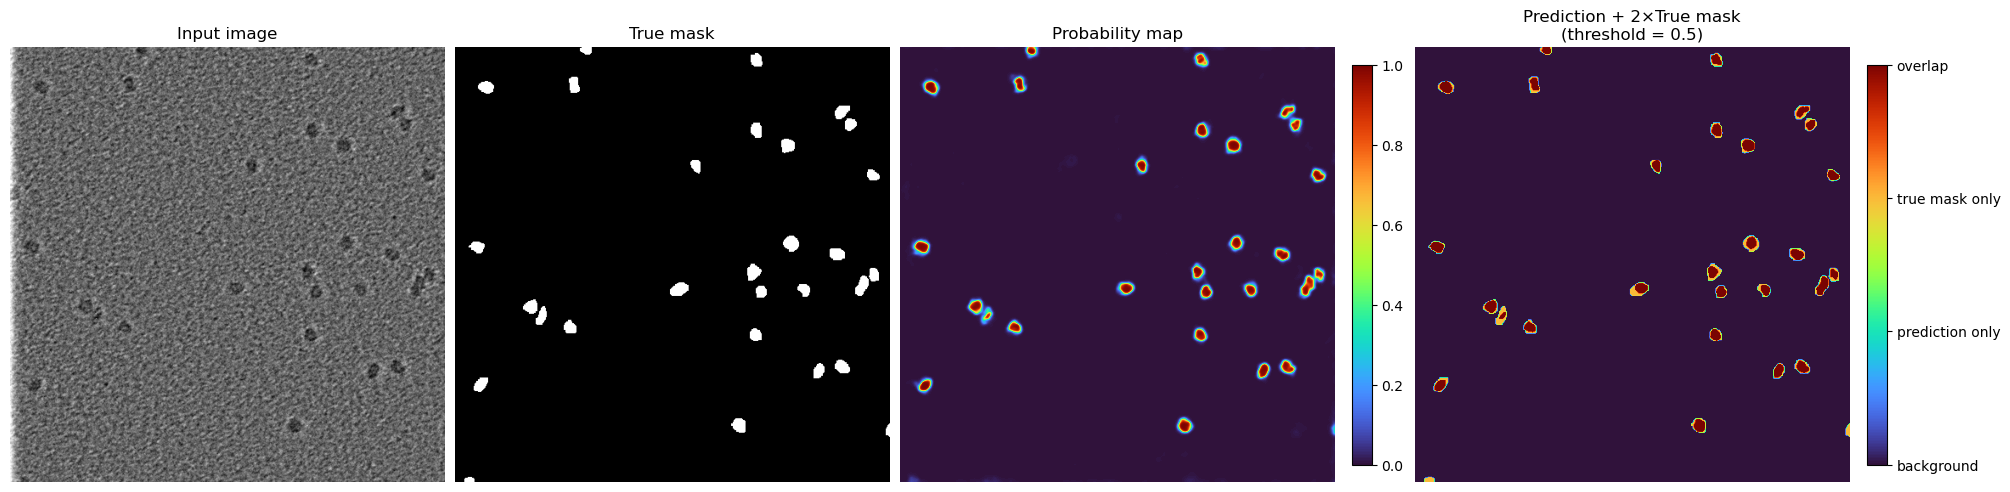

In [15]:
# 14.1 Choose sample and threshold

sample_idx = 42
thr = 0.5
cmap_combined = "turbo"

# 14.2 Load one sample from dataset_test

image, true_mask = dataset_test[sample_idx]

# add batch dimension and move image to device
x = image.unsqueeze(0).to(device).float()

model.eval()
with torch.no_grad():
    logits = model(x)
    prob_map = torch.sigmoid(logits)[0, 0].cpu().numpy()

# 14.3 Prepare arrays for display

img_np = image.squeeze().cpu().numpy()
true_mask_np = true_mask.squeeze().cpu().numpy()

pred_mask_np = (prob_map > thr).astype(np.uint8)

# Combined map:
# 0 = background
# 1 = prediction only
# 2 = ground truth only
# 3 = overlap
combined_map = pred_mask_np + 2 * true_mask_np.astype(np.uint8)

# 14.4 Plot

fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)

axes[0].imshow(img_np, cmap="gray")
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(true_mask_np, cmap="gray")
axes[1].set_title("True mask")
axes[1].axis("off")

im2 = axes[2].imshow(prob_map, cmap="turbo", vmin=0, vmax=1)
axes[2].set_title(f"Probability map")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(combined_map, cmap=cmap_combined, vmin=0, vmax=3)
axes[3].set_title(f"Prediction + 2×True mask\n(threshold = {thr})")
axes[3].axis("off")
cbar = plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)
cbar.set_ticks([0, 1, 2, 3])
cbar.set_ticklabels([
    "background",
    "prediction only",
    "true mask only",
    "overlap"
])

plt.show()

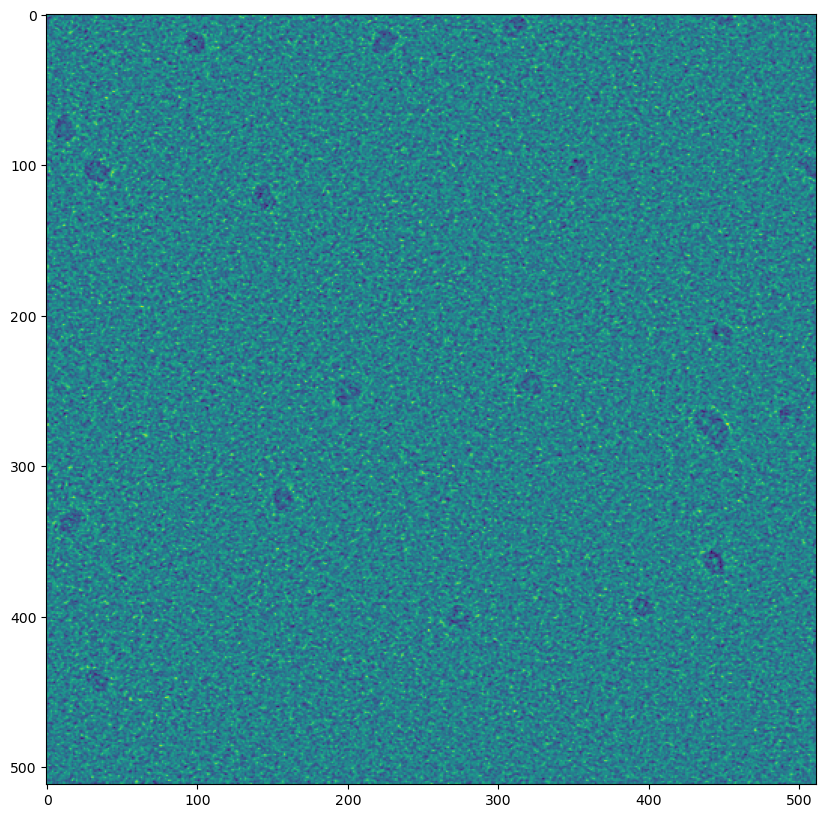

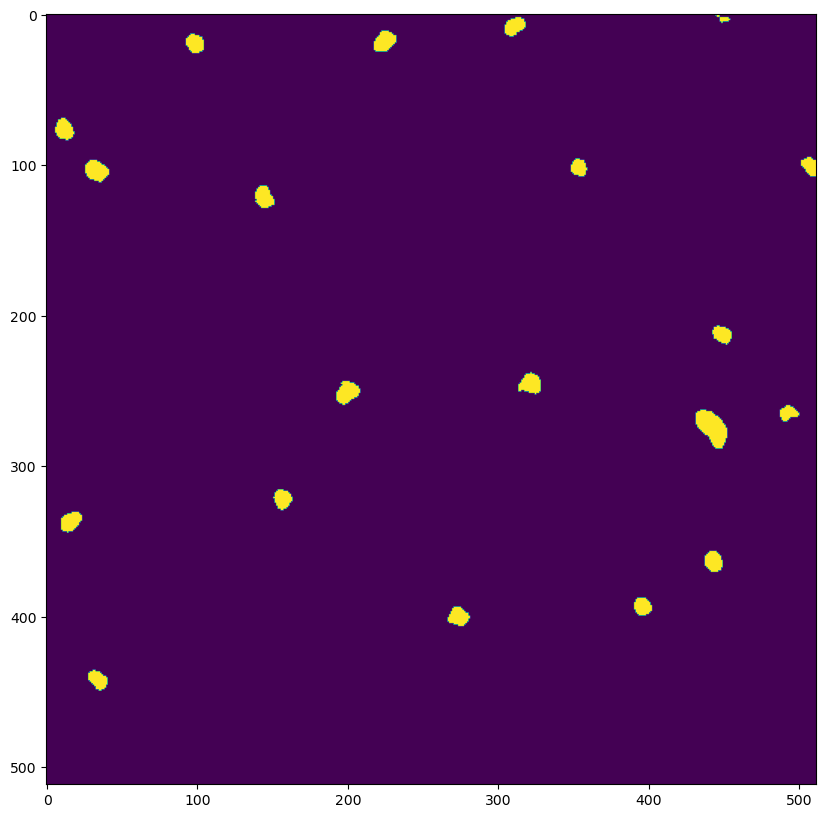

In [16]:
### Plot the image from the test dataset

img_to_test = np.array(dataset_test.__getitem__(117)[0].squeeze())

prob, pred = infer_patch(model.to(device), img_to_test, device)

plt.figure(figsize = (15, 10))
plt.imshow(img_to_test)
plt.show()

plt.figure(figsize = (15, 10))
plt.imshow(prob>0.427)
plt.show()

## 16. Test the model on external images

Until now, the model has been tested on saved dataset patches.

Here we move one step closer to a realistic use case:  
we load images that were not explicitly used in the training workflow and inspect how the model behaves on them.

This is important because a model may perform well on held-out patches from the same prepared dataset, yet behave differently on images coming from a slightly different acquisition context.

Testing on external images is therefore a useful first check of generalization.

In [17]:
### Use files from the batch that haven't been used at all in any step of training

root = r"Agregates for training TP\Co150V_C_A1_TM22-36"

images = [os.path.join(r,file) for r,d,f in os.walk(root)
          for file in f
          if file.lower().endswith('.tiff') and 'mask' not in file.lower()
          and 'Co150V' in r
          ### magnification below 200k
#           and int(file.split('-')[2][:-1]) < 200001
         ]

print("Total %.i images ready for inference" % len(images))

Total 14 images ready for inference


## 17. Read a larger microscopy image

Here we load one larger TIFF image that will be used for prediction outside the patch dataset.

This allows us to move from training-sized crops to more realistic full-image inference.

Large microscopy images are often too big to process in one forward pass, especially for encoder-decoder architectures with many channels.  
That is why tiled inference will be used later.

In [18]:
with TiffFile(images[8]) as tif:
    img = tif.asarray()

## 18. Test inference on a crop from the larger image

Before running tiled inference on the full image, it is useful to try the model on one crop.

This acts as a quick sanity check:

- the image format is correct,
- the model can process the crop,
- the prediction looks plausible,
- the chosen threshold is reasonable.

This is often a good debugging step before launching a larger full-image prediction.

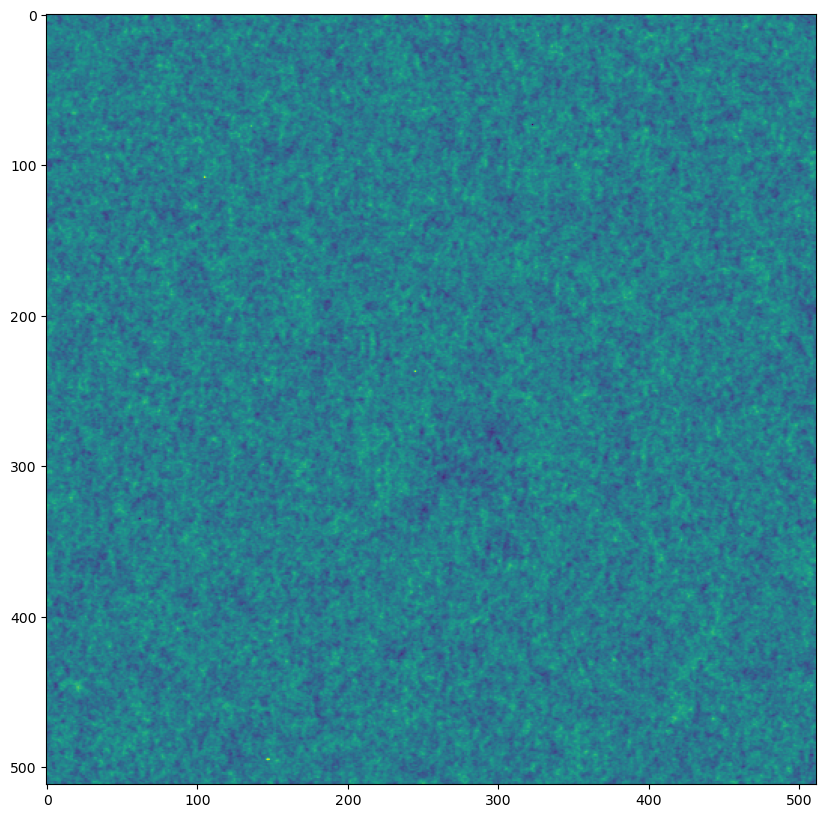

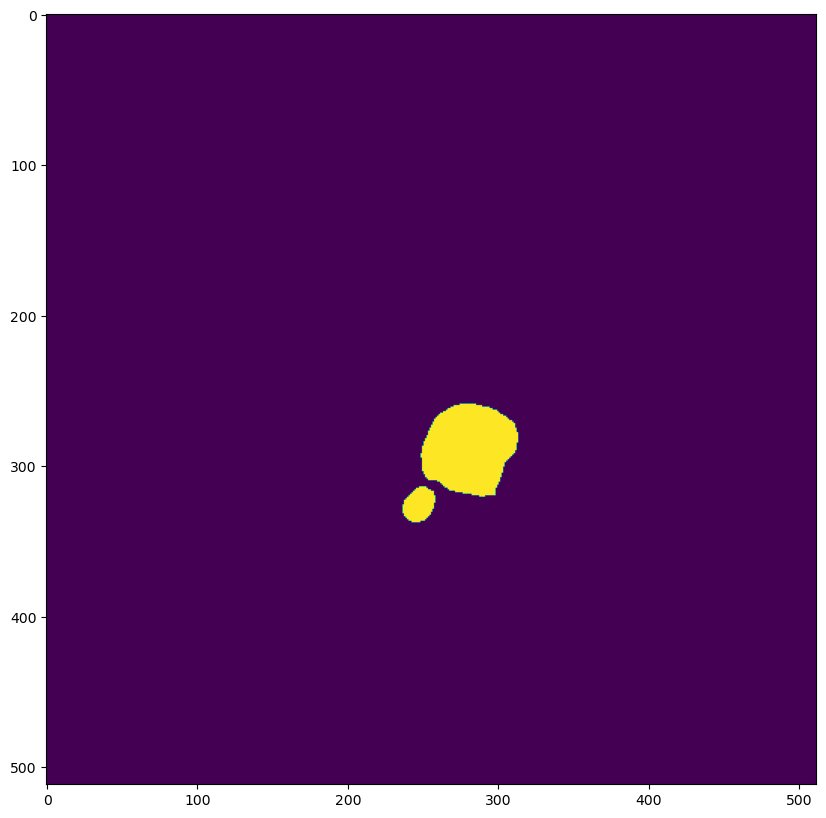

In [19]:
inf_patch = 512

prob, pred = infer_patch(model.to(device),
                         img[500:500+inf_patch,500:500+inf_patch], device)

plt.figure(figsize = (15, 10))
plt.imshow(img[500:500+inf_patch,500:500+inf_patch])
plt.show()

plt.figure(figsize = (15, 10))
plt.imshow(prob>0.4)
plt.show()

## 19. Run tiled inference on the full image

Large images are often too large to process in one pass because of memory limitations.

To solve this, we split the image into overlapping patches, run the model on each patch, and then reconstruct a full probability map.

This approach is called **tiled inference**.

### Why use overlap?

If patches were stitched without overlap, predictions near patch borders could be less reliable because the model sees less surrounding context there.

By using overlap and averaging the probabilities in shared regions, we usually obtain smoother and more stable full-image predictions.

### What is returned?

The tiled inference function returns:

- a **probability map**, containing continuous confidence values,
- a **binary prediction map**, obtained after thresholding.

This is the standard way to extend a patch-based model to larger images.

In [20]:
%%time
prob_map, pred_map = infer_full_image_tiled(
    model.to(device),
    img_np=img,   # HxW
    patch_size=512,
    step=512/2,
    device=next(model.parameters()).device,
    thr=0.5,
    progress = tqdm
)
torch.cuda.empty_cache()

  0%|          | 0/150 [00:00<?, ?it/s]

CPU times: total: 5min 10s
Wall time: 37.4 s


## 20. Visualize the full-image prediction

Finally, we display the original image and the corresponding prediction map.

This type of comparison is useful for qualitative evaluation:

- do the predicted regions align with visible structures?
- are there obvious false positives?
- are some structures systematically missed?
- does the confidence map look sharp or uncertain?

Quantitative metrics are essential during training, but visual inspection remains very important in segmentation tasks, especially in scientific imaging, where the practical usefulness of the result often depends on morphology and interpretability.

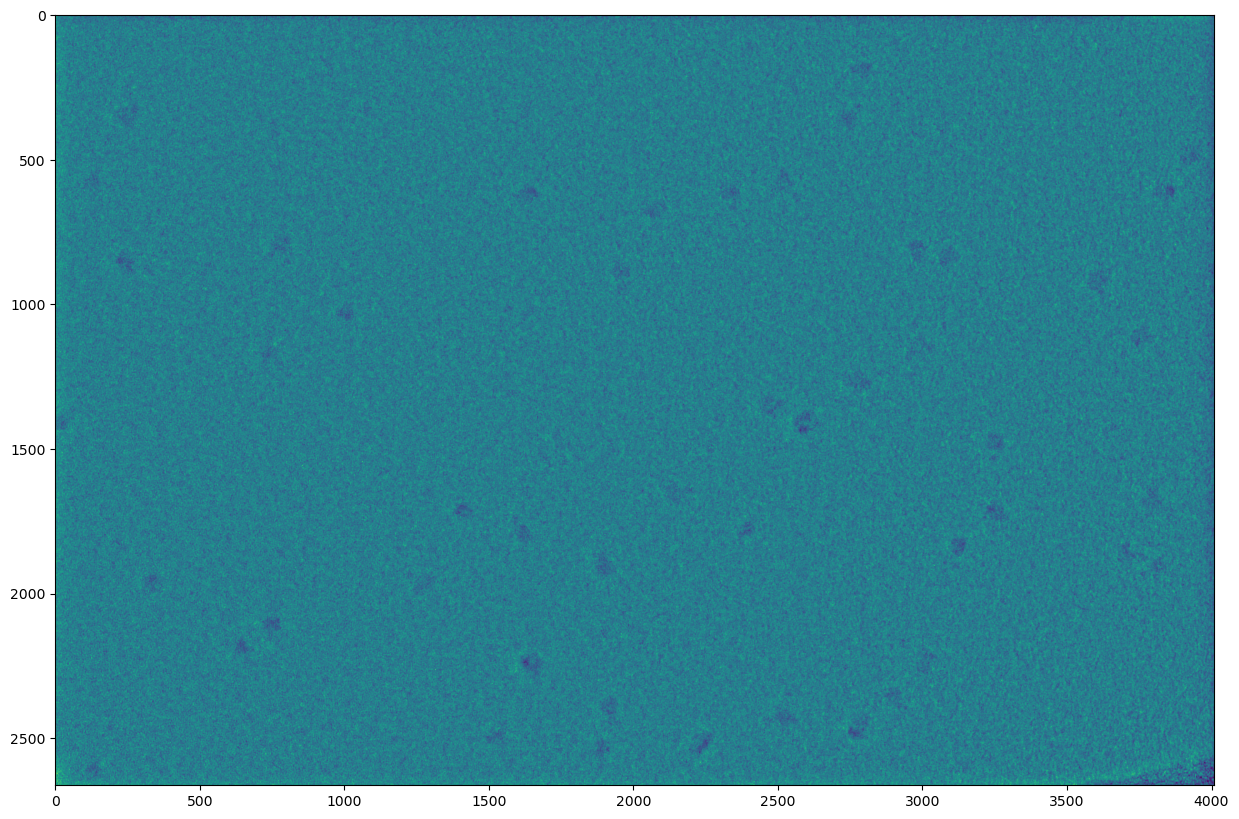

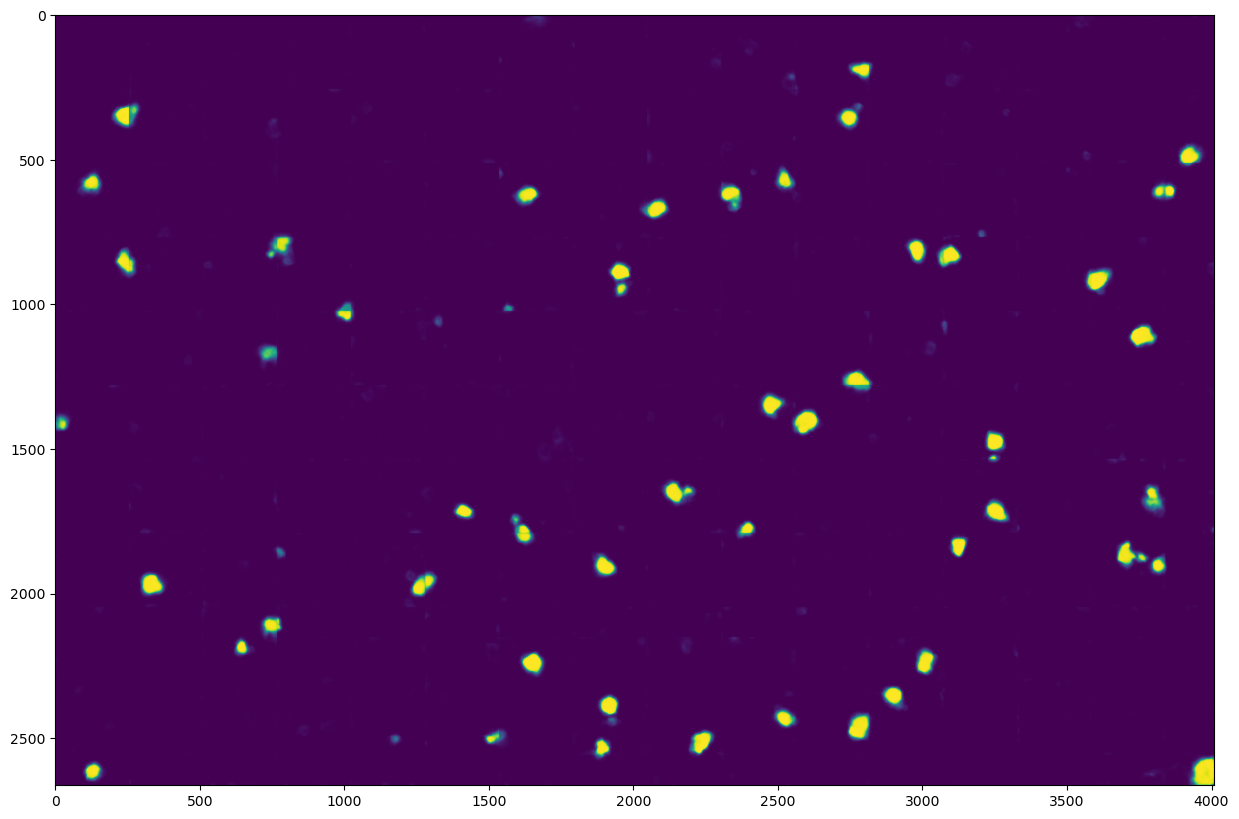

In [21]:
plt.figure(figsize = (15, 10))
plt.imshow(img)
plt.show()
plt.figure(figsize = (15, 10))
plt.imshow(prob_map)
plt.show()

## What we achieved in this notebook

In this notebook, we built a complete segmentation training workflow.

More precisely, we:

- imported the reusable helper functions from the workshop library,
- selected one of several encoder-decoder segmentation architectures,
- loaded the training, validation, and test datasets,
- estimated the foreground imbalance,
- defined the optimizer, scheduler, and loss function,
- trained the model and tracked its history,
- saved and reloaded trained weights,
- ran inference on patches and on larger tiled images.

This notebook is the practical bridge between dataset preparation and real model use.

In the next steps, this same workflow can be extended in several directions:

- comparing architectures,
- comparing losses,
- tuning thresholds,
- improving generalization,
- adding post-processing to remove weak false detections,
- or performing more systematic evaluation on external images.